# Eine Datei: von Rohdaten bis Anomalie- und Wartungsbenchmark

## tl;dr

Dieses Notebook liest ausschließlich die ursprünglichen Dateien unter `data/`, bereinigt
die Messreihen, ordnet Wartungen den HAST zu, bildet die Stundendimension, bestimmt `k`,
trainiert die Modelle und berechnet alle Tabellen und Grafiken neu. 
Im validierten Lauf mit dem aktuellen Datenstand entstehen:

- 78 vergleichbare HAST und 18.518 gemeinsame Stunden,
- zwei langfristige K-Means-Stationsprofile (54 und 24 HAST),
- vier probabilistische 14-Tage-Betriebszustände,
- 30 vollständig zugeordnete Wartungsfenster: 20 bleiben im wahrscheinlichsten Zustand,
  10 wechseln,
- ein unabhängiger Vergleich mehrerer unüberwachter Anomaliescores mit Event Recall,
  Event Precision, Erkennungsverzögerung und Fehlalarm-Läufen.

Die zehn Zustandswechsel sind **operationale Proxy-Anomalien**, keine bestätigten
Fehlerarten. Ab dieser Regel beginnt unsere Interpretation; die davor berechneten Zustände
und Wahrscheinlichkeiten sind Modellergebnisse.

## Context & Methods

### Was „allein ausführbar“ hier bedeutet

Benötigt werden nur dieses Notebook, die Rohdaten und die in `requirements.txt` genannten
Python-Pakete. Die Rohdaten können in `data/raw` und `data/Update-...` liegen; der Pfad wird
automatisch gesucht und kann in der nächsten Zelle überschrieben werden. Rohdaten sind
notwendige Eingaben.

### Die drei Fragen

1. **Stationsprofile:** Welche HAST verhalten sich über den Gesamtzeitraum ähnlich?
2. **Zeitliche Zustände:** Ändert sich das Betriebsprofil einer HAST rund um eine Wartung?
3. **Anomaliedetektion:** Erkennen unabhängige Scores die als auffällig definierten
   Wartungs-Nachherfenster, ohne stabile Nachherfenster ständig zu alarmieren?

### Begriffe, die nicht verwechselt werden dürfen

| Begriff | Was er ist | Was er nicht ist |
|---|---|---|
| K-Means-Cluster | Gruppe ähnlicher Langzeitprofile | Fehlerlabel |
| GMM-Wahrscheinlichkeit | Zugehörigkeit zu einem beobachteten Zustand | Gesundheitswahrscheinlichkeit |
| Anomaliescore | Rang/Abweichungsstärke | bewiesene Fehlerursache |
| Proxy-Label | nachvollziehbare Bewertungsregel | manuell bestätigte Ground Truth |

### Kennzeichnung im Text

- **BERECHNET:** direkt aus Rohdaten oder Modelloutput.
- **METHODISCHE ENTSCHEIDUNG:** Regel, die wir für Vergleichbarkeit festlegen.
- **INTERPRETATION:** fachliche Lesart der berechneten Werte.
- **NICHT BELEGT:** Schluss, den diese Daten nicht tragen.

### Key Assumptions

- Zeitstempel werden als `Europe/Berlin` interpretiert und nach UTC überführt.
- Doppelte Zähler-Zeitpunkte werden per Median zusammengeführt.
- Physikalisch harte Werte werden fehlend gesetzt; nur Lücken bis zwei Stunden werden
  interpoliert.
- Eine HAST braucht mindestens 60 % Kernsignalabdeckung.
- Modellfit und Skalierung verwenden keine Zukunft; Schwellen stammen nur aus der
  Validierung und Wartungsnähe wird dabei ausgeschlossen.
- Ein Alarm zählt erst ab drei zusammenhängenden Stunden.

## Data

### Setup: nur Pfade, Pakete und feste Parameter

In [1]:
from pathlib import Path
from string import ascii_uppercase
from datetime import time
import json
import os
import re
import warnings
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.spatial.distance import jensenshannon
from sklearn.cluster import AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score, average_precision_score, calinski_harabasz_score,
    davies_bouldin_score, roc_auc_score, silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-standalone-anomalie")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# Nur ändern, wenn die automatische Suche die Rohdaten nicht findet.
DATA_ROOT = None  # Beispiel: Path("/pfad/zum/projekt/data")

START = Path.cwd().resolve()
if DATA_ROOT is None:
    data_candidates = []
    for base in [START, *START.parents]:
        data_candidates.extend([base / "data", base])
    DATA_ROOT = next(
        (path for path in data_candidates if (path / "raw").is_dir()), None
    )
else:
    DATA_ROOT = Path(DATA_ROOT).expanduser().resolve()
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Rohdatenordner nicht gefunden. DATA_ROOT auf den Ordner setzen, der 'raw' enthält."
    )

RAW = DATA_ROOT / "raw"
UPDATE_DIR = DATA_ROOT / "Update-Termin_und_Imagefilm_zum_KI-Regio-Projekt"
WORK_ROOT = next(
    (base / "masterarbeit_anomalie" for base in [START, *START.parents]
     if (base / "masterarbeit_anomalie").is_dir()),
    START,
)
OUTPUTS = WORK_ROOT / "outputs" / "standalone_pipeline"
ARTIFACTS = WORK_ROOT / "artifacts" / "standalone_pipeline"
MODELS = WORK_ROOT / "models" / "standalone_pipeline"
for folder in [OUTPUTS, ARTIFACTS, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MIN_COVERAGE = 0.60
MAX_SHORT_GAP_HOURS = 2
STATION_K_VALUES = list(range(2, 9))
TEMPORAL_K_VALUES = list(range(2, 7))
WINDOW_HOURS = 14 * 24
STEP_HOURS = 7 * 24
MIN_ALARM_RUN_HOURS = 3
THRESHOLD_QUANTILE = 0.995

BLUE, ORANGE, OLIVE, PURPLE, INK, MUTED, GRID, LIGHT = (
    "#2563EB", "#D97706", "#6B7D2A", "#8B5CF6",
    "#172033", "#64748B", "#E2E8F0", "#F8FAFC",
)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "axes.titlecolor": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 10,
})
print(f"Rohdaten: {DATA_ROOT}")
print(f"Neu erzeugte Ergebnisse: {ARTIFACTS}")

Rohdaten: /tmp/standalone-notebook.RldTGZ/data
Neu erzeugte Ergebnisse: /tmp/standalone-notebook.RldTGZ/notebooks/artifacts/standalone_pipeline


### Schritt 13 – Rohdaten finden und Zuordnungen prüfen

Zuerst wird nicht modelliert, sondern geprüft, welche Datei welchen Schlüssel liefert.
`Zuordnung.xlsx` verbindet Wartungsadresse und Zählernummer. `Nodes_Edges.ods` verbindet
Zählernummer und logische HAST. Das reicht für die Wartungsanalyse.

Die GIS-Leitungen werden ebenfalls geprüft. Wenn dort weder Zählernummer noch Adresse steht,
fehlt nur die direkte Brücke **HAST → konkretes Leitungssegment**. Das blockiert K-Means,
Zeitfenster und Wartungsbenchmark nicht; es blockiert lediglich eine belastbare räumlich-
hydraulische Zuordnung.

In [2]:
required_files = {
    "Topologie": RAW / "Nodes_Edges.ods",
    "historische Zuordnung": RAW / "Zuordnung.xlsx",
}
zip_paths = sorted(RAW.glob("20*.zip"))
inspection_paths = sorted(RAW.glob("*Ergebnis_Optimierung_FW*.xlsx"))
update_paths = sorted(UPDATE_DIR.glob("*.ods")) if UPDATE_DIR.is_dir() else []
gis_paths = sorted(RAW.glob("Leitungsverlauf_*.*"))
missing_sources = [name for name, path in required_files.items() if not path.is_file()]
if missing_sources or not zip_paths or len(inspection_paths) != 1:
    raise FileNotFoundError(
        f"Fehlende/uneindeutige Rohquellen: {missing_sources}; "
        f"ZIPs={len(zip_paths)}, Wartungsdateien={len(inspection_paths)}"
    )

def export_year(path):
    match = re.search(r"20\d{2}", path.name)
    if match is None:
        raise ValueError(f"Kein Jahr im ZIP-Namen: {path.name}")
    return int(match.group())

selected_zip = max(zip_paths, key=export_year)
topology_path = required_files["Topologie"]
mapping_path = required_files["historische Zuordnung"]
inspection_path = inspection_paths[0]
nodes = pd.read_excel(topology_path, sheet_name="Nodes", engine="odf")
edges = pd.read_excel(topology_path, sheet_name="Edges", engine="odf")
nodes["meter_id"] = (
    pd.to_numeric(nodes["Zählernummer"], errors="coerce").astype("Int64").astype(str)
)
topology_meter_ids = set(nodes.loc[nodes["meter_id"] != "<NA>", "meter_id"])

with zipfile.ZipFile(selected_zip) as archive:
    csv_members = sorted(name for name in archive.namelist() if name.lower().endswith(".csv"))
member_by_meter = {}
for member in csv_members:
    match = re.search(r"(\d+)", Path(member).stem)
    if match:
        member_by_meter[match.group(1)] = member
zip_meter_ids = set(member_by_meter)

gis_columns = []
direct_gis_key_present = False
line_shp = RAW / "Leitungsverlauf_LineString.shp"
if line_shp.is_file():
    try:
        import geopandas as gpd
        pipes = gpd.read_file(line_shp)
        gis_columns = list(map(str, pipes.columns))
        normalized = {column.lower() for column in gis_columns}
        direct_gis_key_present = bool(
            normalized & {"meter_id", "zählernummer", "zaehlernummer", "adresse", "address"}
        )
    except ImportError:
        gis_columns = ["nicht geprüft: geopandas fehlt (für Hauptanalyse optional)"]

source_inventory = pd.DataFrame([
    ["Messreihen", selected_zip.name, len(zip_meter_ids), "Zählernummer", "Hauptanalyse"],
    ["Topologie", topology_path.name, len(nodes), "Zählernummer + Adresse", "HAST-Zuordnung"],
    ["logische Kanten", topology_path.name, len(edges), "Adresse von/nach", "Kontext"],
    ["Wartungen", inspection_path.name, "eine Arbeitsmappe", "Adresse + Datum", "Proxy-Evaluation"],
    ["historische Zuordnung", mapping_path.name, "2024–2026", "Adresse ↔ Zähler", "Wartungs-Merge"],
    ["GIS", f"{len(gis_paths)} Dateien", len(gis_paths), ", ".join(gis_columns[:5]), "Brücken-Audit"],
    ["Update-ODS", f"{len(update_paths)} Dateien", len(update_paths), "Zähler + Zeit", "kleiner OOT-Zusatz"],
], columns=["Quelle", "Datei", "Umfang", "Schlüssel", "Rolle"])
display(source_inventory)

initial_join_audit = pd.DataFrame([
    ["Zähler im neuesten ZIP", len(zip_meter_ids), len(zip_meter_ids)],
    ["davon mit Topologieeintrag", len(zip_meter_ids & topology_meter_ids), len(zip_meter_ids)],
    ["GIS mit direktem Zähler-/Adressschlüssel", int(direct_gis_key_present), 1],
], columns=["Prüfung", "Treffer", "Gesamt"])
initial_join_audit["Quote"] = initial_join_audit["Treffer"] / initial_join_audit["Gesamt"]
display(initial_join_audit.assign(Quote=lambda d: d["Quote"].map(lambda x: f"{x:.1%}")))
display(Markdown(
    "**BERECHNET:** Wartung ↔ Adresse ↔ Zähler/HAST ist möglich. "
    f"Eine direkte HAST↔GIS-Leitungsbrücke ist "
    f"{'vorhanden' if direct_gis_key_present else 'nicht vorhanden'}. "
    "Das ist für diesen Benchmark kein Ausschlussgrund."
))

,Quelle,Datei,Umfang,Schlüssel,Rolle
0,Messreihen,2025[46].zip,96,Zählernummer,Hauptanalyse
1,Topologie,Nodes_Edges.ods,99,Zählernummer + Adresse,HAST-Zuordnung
2,logische Kanten,Nodes_Edges.ods,110,Adresse von/nach,Kontext
3,Wartungen,20252810_Ergebnis_Optimierung_FW[45].xlsx,eine Arbeitsmappe,Adresse + Datum,Proxy-Evaluation
4,historische Zuordnung,Zuordnung.xlsx,2024–2026,Adresse ↔ Zähler,Wartungs-Merge
5,GIS,15 Dateien,15,"DELETED, DX_LBL, DY_LBL, FID, LINIENTYP",Brücken-Audit
6,Update-ODS,5 Dateien,5,Zähler + Zeit,kleiner OOT-Zusatz


,Prüfung,Treffer,Gesamt,Quote
0,Zähler im neuesten ZIP,96,96,100.0%
1,davon mit Topologieeintrag,84,96,87.5%
2,GIS mit direktem Zähler-/Adressschlüssel,0,1,0.0%


**BERECHNET:** Wartung ↔ Adresse ↔ Zähler/HAST ist möglich. Eine direkte HAST↔GIS-Leitungsbrücke ist nicht vorhanden. Das ist für diesen Benchmark kein Ausschlussgrund.

### Schritt 13 – Messreihen bereinigen und auf ein Stundenraster bringen

Die ZIPs sind überlappende Exportstände. Der neueste Export kontrolliert daher die Historie.
Jede Station wird getrennt bereinigt, erst danach wird ein gemeinsames Stundenfenster gebildet.
Originale Fehlwerte bleiben in einer Maske erhalten, auch wenn eine kurze Lücke numerisch
interpoliert wird.

In [3]:
RENAME = {
    "Energy (kWh)": "energy_counter_kwh",
    "Volume flow (l/h)": "flow_lh",
    "Power (kW)": "power_kw",
    "Temperature difference (°C)": "delta_t_c",
    "Flow temperature (°C)": "flow_temp_c",
    "Return temperature (°C)": "return_temp_c",
    "Volume (m³)": "volume_counter_m3",
}
EXPECTED_COLUMNS = {"Timestamp", *RENAME}
CORE_FEATURES = ["flow_lh", "power_kw", "delta_t_c", "flow_temp_c", "return_temp_c"]
ALL_FEATURES = [
    "energy_delta_kwh", "volume_delta_m3", "flow_lh", "power_kw",
    "delta_t_c", "flow_temp_c", "return_temp_c", "physics_residual_kw",
]
candidate_ids = sorted(zip_meter_ids & topology_meter_ids)
cleaned = {}
cleaning_rows = []

with zipfile.ZipFile(selected_zip) as archive:
    for meter_id in candidate_ids:
        with archive.open(member_by_meter[meter_id]) as handle:
            frame = pd.read_csv(handle)
        missing_columns = sorted(EXPECTED_COLUMNS - set(frame.columns))
        if missing_columns:
            raise ValueError(f"Pflichtspalten fehlen für einen Zähler: {missing_columns}")
        rows_raw = len(frame)
        frame = frame.rename(columns=RENAME)
        frame["Timestamp"] = pd.to_datetime(frame["Timestamp"], errors="coerce")
        invalid_timestamps = int(frame["Timestamp"].isna().sum())
        frame = frame.dropna(subset=["Timestamp"])
        numeric_columns = list(RENAME.values())
        frame[numeric_columns] = frame[numeric_columns].apply(pd.to_numeric, errors="coerce")
        duplicate_rows = int(frame["Timestamp"].duplicated(keep=False).sum())
        frame = frame.groupby("Timestamp")[numeric_columns].median().sort_index()

        localized = frame.index.tz_localize(
            "Europe/Berlin", ambiguous="NaT", nonexistent="shift_forward"
        )
        keep = ~localized.isna()
        ambiguous_times = int((~keep).sum())
        frame = frame.loc[keep]
        frame.index = localized[keep].tz_convert("UTC").tz_localize(None)
        frame = frame[~frame.index.duplicated(keep="last")].sort_index()

        hard_invalid = pd.DataFrame(False, index=frame.index, columns=CORE_FEATURES)
        hard_invalid["flow_lh"] = (frame["flow_lh"] < 0) | (frame["flow_lh"] > 50_000)
        hard_invalid["power_kw"] = (frame["power_kw"] < 0) | (frame["power_kw"] > 2_000)
        hard_invalid["delta_t_c"] = (frame["delta_t_c"] < -60) | (frame["delta_t_c"] > 100)
        hard_invalid["flow_temp_c"] = (frame["flow_temp_c"] < -20) | (frame["flow_temp_c"] > 130)
        hard_invalid["return_temp_c"] = (frame["return_temp_c"] < -20) | (frame["return_temp_c"] > 130)
        frame[CORE_FEATURES] = frame[CORE_FEATURES].mask(hard_invalid)

        counters = frame[["energy_counter_kwh", "volume_counter_m3"]].resample("h").last()
        states = frame[CORE_FEATURES].resample("h").median()
        hourly = counters.join(states, how="outer")
        hourly["energy_delta_kwh"] = hourly["energy_counter_kwh"].diff().mask(lambda s: s < 0)
        hourly["volume_delta_m3"] = hourly["volume_counter_m3"].diff().mask(lambda s: s < 0)
        expected_power = hourly["flow_lh"] * 4.186 * hourly["delta_t_c"] / 3600.0
        hourly["physics_residual_kw"] = hourly["power_kw"] - expected_power
        cleaned[meter_id] = hourly
        cleaning_rows.append({
            "rows_raw": rows_raw, "invalid_timestamps": invalid_timestamps,
            "duplicate_rows": duplicate_rows, "ambiguous_times": ambiguous_times,
            "hard_invalid_cells": int(hard_invalid.sum().sum()),
            "start": hourly.index.min(), "end": hourly.index.max(),
        })

start_candidates = pd.Series([frame.index.min() for frame in cleaned.values()])
end_candidates = pd.Series([frame.index.max() for frame in cleaned.values()])
analysis_start = start_candidates.quantile(0.50).ceil("h")
analysis_end = end_candidates.quantile(0.05).floor("h")
timestamps = pd.date_range(analysis_start, analysis_end, freq="h")
coverage_by_meter = {
    meter_id: cleaned[meter_id].reindex(timestamps)[CORE_FEATURES].notna().mean().mean()
    for meter_id in candidate_ids
}
selected_ids = sorted(
    meter_id for meter_id, coverage in coverage_by_meter.items()
    if coverage >= MIN_COVERAGE
)
if len(selected_ids) < 10:
    raise RuntimeError("Zu wenige Stationen erfüllen die 60%-Abdeckung.")

metadata_private = nodes.loc[nodes["meter_id"].isin(selected_ids)].copy()
metadata_private = metadata_private.set_index("meter_id").reindex(selected_ids).reset_index()
metadata_private = metadata_private.rename(columns={"Straße": "address", "Anschlusswert": "contract_kw"})
metadata_private["contract_kw"] = pd.to_numeric(metadata_private["contract_kw"], errors="coerce")
metadata_private["node_code"] = [f"HAST-{index + 1:03d}" for index in range(len(metadata_private))]
if metadata_private["contract_kw"].isna().any() or (metadata_private["contract_kw"] <= 0).any():
    raise ValueError("Anschlusswerte fehlen oder sind nicht positiv.")

values = np.full((len(timestamps), len(selected_ids), len(ALL_FEATURES)), np.nan, dtype=np.float32)
original_missing = np.ones_like(values, dtype=np.uint8)
for station, meter_id in enumerate(selected_ids):
    aligned = cleaned[meter_id].reindex(timestamps)[ALL_FEATURES]
    original_missing[:, station] = aligned.isna().to_numpy(np.uint8)
    values[:, station] = aligned.interpolate(
        method="linear", limit=MAX_SHORT_GAP_HOURS, limit_area="inside"
    ).to_numpy(np.float32)
del cleaned

feature_index = {name: index for index, name in enumerate(ALL_FEATURES)}
meter_ids = np.asarray(selected_ids)
node_codes = metadata_private["node_code"].astype(str).to_numpy()
contracts = metadata_private["contract_kw"].to_numpy(float)
cleaning_audit = pd.DataFrame(cleaning_rows)
data_funnel = pd.DataFrame([
    ["Mess-Zähler im neuesten Export", len(zip_meter_ids)],
    ["mit Eintrag in der logischen Topologie", len(candidate_ids)],
    ["mit mindestens 60 % Kernabdeckung", len(selected_ids)],
    ["gemeinsame UTC-Stunden", len(timestamps)],
], columns=["Stufe", "Anzahl"])
display(data_funnel)
display(pd.DataFrame([
    ["Analysezeitraum UTC", f"{timestamps.min()} bis {timestamps.max()}"],
    ["ursprünglich fehlende Zellen", f"{original_missing.mean():.2%}"],
    ["betroffene Duplikatzeilen", f"{cleaning_audit['duplicate_rows'].sum():,}"],
    ["hart maskierte Messzellen", f"{cleaning_audit['hard_invalid_cells'].sum():,}"],
], columns=["Prüfung", "Ergebnis"]))

,Stufe,Anzahl
0,Mess-Zähler im neuesten Export,96
1,mit Eintrag in der logischen Topologie,84
2,mit mindestens 60 % Kernabdeckung,78
3,gemeinsame UTC-Stunden,18518


,Prüfung,Ergebnis
0,Analysezeitraum UTC,2023-05-31 21:00:00 bis 2025-07-11 10:00:00
1,ursprünglich fehlende Zellen,29.13%
2,betroffene Duplikatzeilen,"45,555"
3,hart maskierte Messzellen,"10,556"


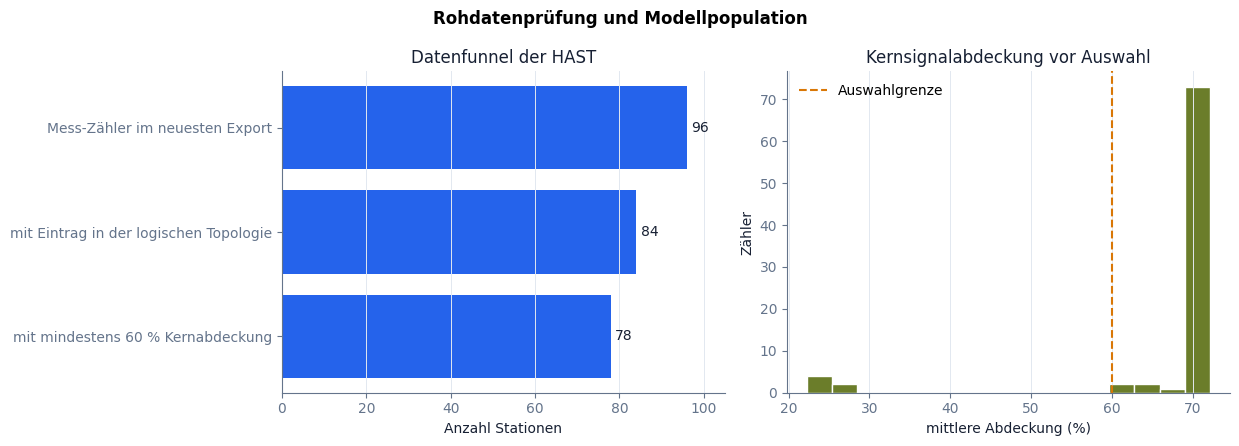

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
funnel_plot = data_funnel.iloc[:3]
axes[0].barh(funnel_plot["Stufe"], funnel_plot["Anzahl"], color=BLUE)
axes[0].invert_yaxis()
axes[0].set(title="Datenfunnel der HAST", xlabel="Anzahl Stationen", xlim=(0, 105))
for index, value in enumerate(funnel_plot["Anzahl"]):
    axes[0].text(value + 1, index, str(value), va="center", color=INK)

coverage_values = pd.Series(coverage_by_meter)
axes[1].hist(coverage_values * 100, bins=16, color=OLIVE, edgecolor="white")
axes[1].axvline(MIN_COVERAGE * 100, color=ORANGE, linestyle="--", label="Auswahlgrenze")
axes[1].set(title="Kernsignalabdeckung vor Auswahl", xlabel="mittlere Abdeckung (%)", ylabel="Zähler")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(axis="x", color=GRID, linewidth=.7)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Rohdatenprüfung und Modellpopulation", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUTS / "01_datenfunnel.png", dpi=180, bbox_inches="tight")
plt.show()

### Schritt 13 – Wartungen eindeutig den HAST zuordnen

Die Zuordnung nutzt alle Jahre aus `Zuordnung.xlsx`, weil Zählernummern wechseln können.
Eine Wartung wird nur übernommen, wenn unter den historischen Kandidaten genau eine aktuell
modellierte Zählernummer liegt. Die Adresse bleibt privat im Arbeitsspeicher; Ausgaben nutzen
nur `HAST-xxx`.

In [5]:
def normalize_address(value):
    if pd.isna(value):
        return ""
    text = str(value).lower().strip()
    for source, target in [("ß", "ss"), ("ä", "ae"), ("ö", "oe"), ("ü", "ue")]:
        text = text.replace(source, target)
    text = re.sub(r"\.", "", text)
    text = re.sub(r"str(asse)?\b", "strasse", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9 \-]", "", text)
    text = re.sub(r"(\d)\s+([a-z])\b", r"\1\2", text)
    return re.sub(r"\s*\-\s*", "-", text).strip()

def clean_house_number(value):
    if pd.isna(value):
        return ""
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return str(int(value))
    return re.sub(r"\.0$", "", str(value).strip())

def yes_flag(series):
    return series.astype(str).str.strip().str.lower().isin({"ja", "yes", "x", "1", "true"})

def extract_clock(value):
    if pd.isna(value):
        return None
    if isinstance(value, time):
        return value
    if hasattr(value, "time"):
        return value.time()
    parsed = pd.to_datetime(str(value), errors="coerce")
    return None if pd.isna(parsed) else parsed.time()

def local_visit_timestamp(date_value, clock_value, fallback_hour=12):
    if pd.isna(date_value):
        return pd.NaT
    clock = extract_clock(clock_value) or time(fallback_hour, 0)
    local = pd.Timestamp.combine(pd.Timestamp(date_value).date(), clock)
    localized = local.tz_localize("Europe/Berlin", ambiguous="NaT", nonexistent="shift_forward")
    return pd.NaT if pd.isna(localized) else localized.tz_convert("UTC").tz_localize(None)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Data Validation extension is not supported.*")
    raw_visits = pd.read_excel(inspection_path, sheet_name="Tabelle1")
visits = raw_visits.loc[
    pd.to_numeric(raw_visits["Nr. "], errors="coerce").notna()
    & raw_visits["Straßenname"].notna() & raw_visits["Hausnummer"].notna()
].copy().reset_index(drop=True)
visits["visit_id"] = [f"W{index:03d}" for index in range(1, len(visits) + 1)]
visits["address_norm"] = (
    visits["Straßenname"].astype(str).str.replace("Fleider", "Flieder", regex=False)
    + " " + visits["Hausnummer"].map(clean_house_number)
).map(normalize_address)
visits["visit_date"] = pd.to_datetime(visits["Datum"], errors="coerce", format="mixed", dayfirst=True)

action_columns = {
    "filter_cleaned": "Filter\ngereinigt",
    "flow_adjusted": "Durchfluss neu\neingestellt",
    "insulation_improved": "Leitungen\nneu gedämmt ",
    "actuator_replaced": "Stellmotor\ngetauscht",
    "valve_replaced": "Stellventil\ngetauscht",
    "controller_replaced": "Regler\ngetauscht",
}
for target, source in action_columns.items():
    visits[target] = yes_flag(visits[source])
contract_old = pd.to_numeric(visits["Vertragsleistung alt"], errors="coerce")
contract_new = pd.to_numeric(visits["Vertragsleistung neu"], errors="coerce")
visits["contract_changed"] = contract_old.notna() & contract_new.notna() & (contract_old != contract_new)
action_names = [*action_columns, "contract_changed"]
visits["n_actions"] = visits[action_names].sum(axis=1).astype(int)
visits["action_confirmed"] = visits["n_actions"] > 0
visits["actions"] = visits.apply(
    lambda row: ";".join(name for name in action_names if bool(row[name])) or "none_recorded", axis=1
)

mapping_parts = []
for year in ["2024", "2025"]:
    frame = pd.read_excel(mapping_path, sheet_name=year)
    frame = frame[["Zählernummer", "Abnahmestelle"]].rename(
        columns={"Zählernummer": "meter_id", "Abnahmestelle": "address"}
    )
    frame["mapping_year"] = year
    mapping_parts.append(frame)
frame = pd.read_excel(mapping_path, sheet_name="2026")
frame = frame[["Zählernr.", "Straße", "Hausnr."]].rename(columns={"Zählernr.": "meter_id"})
frame["address"] = frame["Straße"].astype(str) + " " + frame["Hausnr."].map(clean_house_number)
frame["mapping_year"] = "2026"
mapping_parts.append(frame[["meter_id", "address", "mapping_year"]])

mapping = pd.concat(mapping_parts, ignore_index=True)
mapping["meter_id"] = pd.to_numeric(mapping["meter_id"], errors="coerce").astype("Int64").astype(str)
mapping["address_norm"] = mapping["address"].map(normalize_address)
mapping = mapping.loc[
    (mapping["meter_id"] != "<NA>") & (mapping["address_norm"] != ""),
    ["address_norm", "meter_id", "mapping_year"],
].drop_duplicates()
candidates_by_address = mapping.groupby("address_norm")["meter_id"].agg(lambda values: sorted(set(values)))
selected_meter_ids = set(selected_ids)

def resolve_meter(address):
    candidates = candidates_by_address.get(address, [])
    selected = sorted(set(candidates) & selected_meter_ids)
    if len(selected) == 1:
        return selected[0], "unique_selected"
    if len(selected) > 1:
        return None, "ambiguous_selected"
    return None, "not_in_model" if candidates else "no_mapping"

visits[["meter_id", "mapping_status"]] = pd.DataFrame(
    visits["address_norm"].map(resolve_meter).tolist(), index=visits.index
)
visits["in_selected_pipeline"] = visits["meter_id"].isin(selected_meter_ids)
code_by_meter = metadata_private.set_index("meter_id")["node_code"].to_dict()
node_index_by_meter = {meter_id: index for index, meter_id in enumerate(meter_ids)}
visits["node_code"] = visits["meter_id"].map(code_by_meter)
visits["node_index"] = visits["meter_id"].map(node_index_by_meter)
visits["visit_start_utc"] = [
    local_visit_timestamp(date_value, clock_value)
    for date_value, clock_value in zip(visits["visit_date"], visits["Dauer (Uhrzeit)"])
]
visits["visit_end_utc"] = [
    local_visit_timestamp(date_value, clock_value, fallback_hour=13)
    for date_value, clock_value in zip(visits["visit_date"], visits["Unnamed: 5"])
]
missing_end = visits["visit_end_utc"].isna() & visits["visit_start_utc"].notna()
visits.loc[missing_end, "visit_end_utc"] = visits.loc[missing_end, "visit_start_utc"] + pd.Timedelta(hours=1)
crosses_midnight = visits["visit_end_utc"] <= visits["visit_start_utc"]
visits.loc[crosses_midnight, "visit_end_utc"] += pd.Timedelta(days=1)
visits["pre_start_utc"] = visits["visit_start_utc"] - pd.Timedelta(days=14)
visits["pre_end_utc"] = visits["visit_start_utc"] - pd.Timedelta(hours=1)
visits["post_start_utc"] = visits["visit_end_utc"] + pd.Timedelta(days=1)
visits["post_end_utc"] = visits["visit_end_utc"] + pd.Timedelta(days=15)
visits["full_pre_post_available"] = (
    (visits["pre_start_utc"] >= timestamps.min())
    & (visits["post_end_utc"] <= timestamps.max())
)
train_end = int(len(timestamps) * 0.60)
val_end = int(len(timestamps) * 0.80)
visits["evaluation_eligible"] = (
    visits["in_selected_pipeline"] & visits["action_confirmed"]
    & visits["visit_start_utc"].notna() & visits["full_pre_post_available"]
    & (visits["visit_start_utc"] >= timestamps[train_end])
)
eligible_visits = visits.loc[visits["evaluation_eligible"]].copy()

maintenance_exclusion = np.zeros((len(timestamps), len(meter_ids)), dtype=bool)
for visit in visits.loc[
    visits["in_selected_pipeline"] & visits["visit_start_utc"].notna()
].itertuples(index=False):
    station = int(visit.node_index)
    start = visit.visit_start_utc - pd.Timedelta(days=28)
    end = visit.visit_end_utc + pd.Timedelta(days=7)
    maintenance_exclusion[(timestamps >= start) & (timestamps <= end), station] = True

maintenance_audit = pd.DataFrame([
    ["Vor-Ort-Zeilen", len(visits), len(visits)],
    ["eindeutig auf Modell-HAST abgebildet", int(visits["in_selected_pipeline"].sum()), len(visits)],
    ["mit dokumentierter Maßnahme", int(visits["action_confirmed"].sum()), len(visits)],
    ["vollständige auswertbare Vorher-/Nachherfenster", len(eligible_visits), len(visits)],
], columns=["Prüfung", "Treffer", "Gesamt"])
maintenance_audit["Quote"] = maintenance_audit["Treffer"] / maintenance_audit["Gesamt"]
display(maintenance_audit.assign(Quote=lambda d: d["Quote"].map(lambda x: f"{x:.1%}")))

,Prüfung,Treffer,Gesamt,Quote
0,Vor-Ort-Zeilen,66,66,100.0%
1,eindeutig auf Modell-HAST abgebildet,50,66,75.8%
2,mit dokumentierter Maßnahme,50,66,75.8%
3,vollständige auswertbare Vorher-/Nachherfenster,30,66,45.5%


## Results

### Schritt 14 – Langfristige Stationsprofile mit K-Means

Eine Beobachtung ist jetzt **eine HAST**, nicht eine Stunde. Acht robuste Merkmale fassen
Leistung, Aktivität, Durchfluss, Temperaturen, Physikresiduum, Anschlusswert und Missingness
zusammen. `k` wird nicht nach Optik gewählt: Lösungen mit zu kleinen Gruppen werden verworfen;
anschließend zählen Trennung, zeitliche Stabilität und Startwertstabilität.

In [6]:
STATION_FEATURES = [
    "log_contract_kw", "load_p95_share", "active_hour_share",
    "flow_p95_per_contract", "return_temp_median_c",
    "delta_t_active_median_c", "physics_residual_relative", "missing_rate",
]
core_indices = [feature_index[name] for name in CORE_FEATURES]

def summarize_station(station, start=0, end=None):
    end = len(timestamps) if end is None else end
    station_values = values[start:end, station]
    contract = contracts[station]
    power = station_values[:, feature_index["power_kw"]]
    flow = station_values[:, feature_index["flow_lh"]]
    delta_t = station_values[:, feature_index["delta_t_c"]]
    return_temp = station_values[:, feature_index["return_temp_c"]]
    residual = station_values[:, feature_index["physics_residual_kw"]]
    active = power > 0.5
    active_return = return_temp[active & np.isfinite(return_temp)]
    active_delta = delta_t[active & np.isfinite(delta_t)]
    power_p95 = float(np.nanquantile(power, 0.95))
    return {
        "meter_id": meter_ids[station], "node_code": node_codes[station],
        "contract_kw": contract, "log_contract_kw": np.log1p(contract),
        "load_p95_share": power_p95 / contract,
        "active_hour_share": float(np.nanmean(np.where(np.isnan(power), np.nan, active))),
        "flow_p95_per_contract": float(np.nanquantile(flow, 0.95)) / contract,
        "return_temp_median_c": float(np.median(active_return)) if len(active_return) else np.nan,
        "delta_t_active_median_c": float(np.median(active_delta)) if len(active_delta) else np.nan,
        "physics_residual_relative": float(np.nanmedian(np.abs(residual))) / max(power_p95, 0.1),
        "missing_rate": float(original_missing[start:end, station][:, core_indices].mean()),
    }

midpoint = len(timestamps) // 2
station_private = pd.DataFrame([summarize_station(station) for station in range(len(meter_ids))])
station_early = pd.DataFrame([summarize_station(station, 0, midpoint) for station in range(len(meter_ids))])
station_late = pd.DataFrame([summarize_station(station, midpoint, len(timestamps)) for station in range(len(meter_ids))])

def prepare_station_features(frame):
    source = frame[STATION_FEATURES].replace([np.inf, -np.inf], np.nan)
    imputer_local = SimpleImputer(strategy="median")
    imputed = pd.DataFrame(imputer_local.fit_transform(source), columns=STATION_FEATURES)
    bounds_local = {column: tuple(imputed[column].quantile([0.01, 0.99])) for column in STATION_FEATURES}
    clipped = imputed.copy()
    for column, (lower, upper) in bounds_local.items():
        clipped[column] = clipped[column].clip(lower, upper)
    scaler_local = StandardScaler()
    return scaler_local.fit_transform(clipped), imputer_local, bounds_local, scaler_local

X_station, station_imputer, station_bounds, station_scaler = prepare_station_features(station_private)
X_early, _, _, _ = prepare_station_features(station_early)
X_late, _, _, _ = prepare_station_features(station_late)
minimum_cluster_size = max(5, int(np.ceil(0.10 * len(X_station))))

k_rows = []
station_models = {}
for k in STATION_K_VALUES:
    model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_station)
    labels = model.labels_
    early_labels = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_early)
    late_labels = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_late)
    seed_stability = np.mean([
        adjusted_rand_score(
            labels,
            KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(X_station),
        ) for seed in range(10)
    ])
    sizes = np.bincount(labels, minlength=k)
    k_rows.append({
        "k": k, "silhouette": silhouette_score(X_station, labels),
        "calinski_harabasz": calinski_harabasz_score(X_station, labels),
        "davies_bouldin": davies_bouldin_score(X_station, labels),
        "temporal_ari": adjusted_rand_score(early_labels, late_labels),
        "seed_stability_ari": seed_stability,
        "smallest_cluster": int(sizes.min()), "largest_cluster": int(sizes.max()),
    })
    station_models[k] = model

station_k_metrics = pd.DataFrame(k_rows)
station_k_metrics["eligible"] = station_k_metrics["smallest_cluster"] >= minimum_cluster_size
eligible_index = station_k_metrics.index[station_k_metrics["eligible"]]
rank_parts = []
for metric, ascending in {
    "silhouette": False, "calinski_harabasz": False, "davies_bouldin": True,
    "temporal_ari": False, "seed_stability_ari": False,
}.items():
    ranks = station_k_metrics.loc[eligible_index, metric].rank(ascending=ascending)
    rank_parts.append(1 - (ranks - 1) / max(len(ranks) - 1, 1))
station_k_metrics["selection_score"] = np.nan
station_k_metrics.loc[eligible_index, "selection_score"] = pd.concat(rank_parts, axis=1).mean(axis=1)
selected_station_k = int(
    station_k_metrics.loc[eligible_index]
    .sort_values(["selection_score", "silhouette"], ascending=[False, False]).iloc[0]["k"]
)
kmeans_station = station_models[selected_station_k]
raw_labels = kmeans_station.labels_
raw_profiles = station_private.assign(raw_cluster=raw_labels).groupby("raw_cluster")[STATION_FEATURES].median()
ordered_raw_clusters = raw_profiles.sort_values(["return_temp_median_c", "active_hour_share"]).index.tolist()
raw_to_cluster = {raw: cluster for cluster, raw in enumerate(ordered_raw_clusters)}
station_private["cluster"] = pd.Series(raw_labels).map(raw_to_cluster).to_numpy()
station_private["profile"] = station_private["cluster"].map(
    {cluster: f"Profil {ascii_uppercase[cluster]}" for cluster in range(selected_station_k)}
)
remapped_centers = np.vstack([kmeans_station.cluster_centers_[raw] for raw in ordered_raw_clusters])
distances = np.linalg.norm(X_station[:, None] - remapped_centers[None], axis=2)
station_private["score_kmeans_distance"] = distances[
    np.arange(len(X_station)), station_private["cluster"].to_numpy()
]
cluster_summary = station_private.groupby(["cluster", "profile"]).agg(
    stations=("node_code", "size"), median_contract_kw=("contract_kw", "median"),
    median_load_p95_share=("load_p95_share", "median"),
    median_active_hour_share=("active_hour_share", "median"),
    median_return_temp_c=("return_temp_median_c", "median"),
    median_delta_t_c=("delta_t_active_median_c", "median"),
).reset_index()
display(station_k_metrics.round(3))
display(cluster_summary.round(3))
print(f"METHODISCHE ENTSCHEIDUNG: gemeinsame K-Means-Arbeitslösung k={selected_station_k}")

,k,silhouette,calinski_harabasz,davies_bouldin,temporal_ari,seed_stability_ari,smallest_cluster,largest_cluster,eligible,selection_score
0,2,0.265,26.730,1.507,0.710,1.000,24,54,True,1.000
1,3,0.200,21.954,1.598,0.198,0.989,18,30,True,0.000
2,4,0.221,21.621,1.302,0.202,0.814,3,29,False,NaN
3,5,0.234,22.666,1.176,0.319,0.846,4,23,False,NaN
4,6,0.222,21.343,1.326,0.255,0.603,3,18,False,NaN
5,7,0.227,21.345,1.240,0.272,0.706,4,19,False,NaN
6,8,0.218,20.302,1.225,0.305,0.642,3,18,False,NaN


,cluster,profile,stations,median_contract_kw,median_load_p95_share,median_active_hour_share,median_return_temp_c,median_delta_t_c
0,0,Profil A,54,10.000,0.670,0.496,40.050,29.500
1,1,Profil B,24,10.000,0.612,0.597,57.650,15.000


METHODISCHE ENTSCHEIDUNG: gemeinsame K-Means-Arbeitslösung k=2


,Verfahren,k,Silhouette,Davies-Bouldin,zeitlicher ARI,kleinste Gruppe
0,K-Means,2,0.265,1.507,0.710,24
1,Gaussian Mixture,2,0.343,1.372,0.018,5
2,Agglomerativ (Ward),2,0.280,1.461,0.181,20


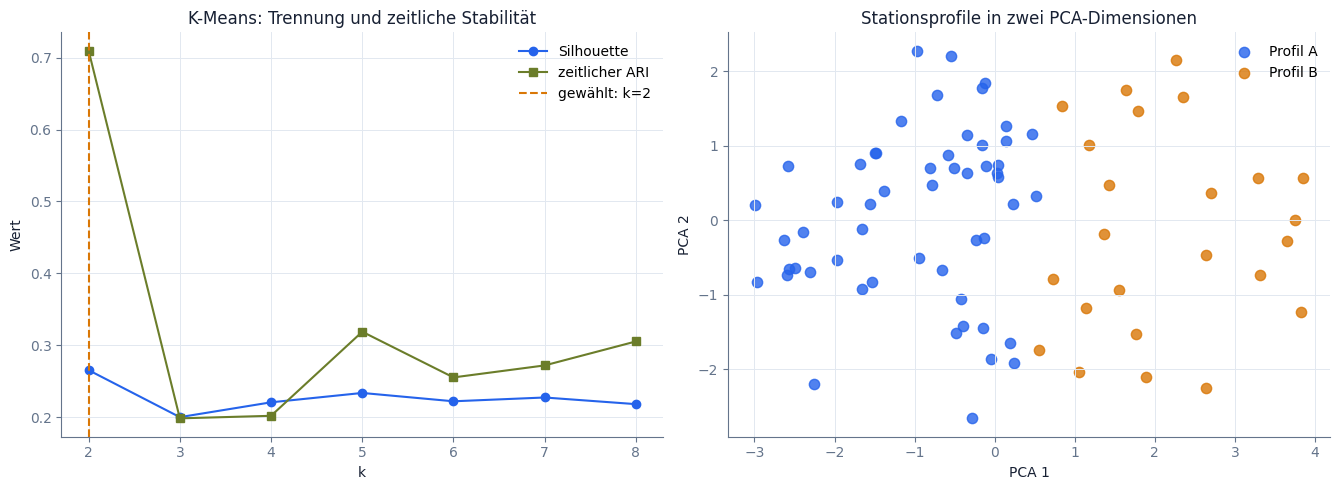

In [7]:
comparison_rows = []
for method in ["K-Means", "Gaussian Mixture", "Agglomerativ (Ward)"]:
    if method == "K-Means":
        labels = KMeans(n_clusters=selected_station_k, n_init=50, random_state=42).fit_predict(X_station)
        early = KMeans(n_clusters=selected_station_k, n_init=50, random_state=42).fit_predict(X_early)
        late = KMeans(n_clusters=selected_station_k, n_init=50, random_state=42).fit_predict(X_late)
    elif method == "Gaussian Mixture":
        labels = GaussianMixture(n_components=selected_station_k, covariance_type="diag", n_init=20, random_state=42).fit_predict(X_station)
        early = GaussianMixture(n_components=selected_station_k, covariance_type="diag", n_init=20, random_state=42).fit_predict(X_early)
        late = GaussianMixture(n_components=selected_station_k, covariance_type="diag", n_init=20, random_state=42).fit_predict(X_late)
    else:
        labels = AgglomerativeClustering(n_clusters=selected_station_k, linkage="ward").fit_predict(X_station)
        early = AgglomerativeClustering(n_clusters=selected_station_k, linkage="ward").fit_predict(X_early)
        late = AgglomerativeClustering(n_clusters=selected_station_k, linkage="ward").fit_predict(X_late)
    sizes = np.bincount(labels, minlength=selected_station_k)
    comparison_rows.append({
        "Verfahren": method, "k": selected_station_k,
        "Silhouette": silhouette_score(X_station, labels),
        "Davies-Bouldin": davies_bouldin_score(X_station, labels),
        "zeitlicher ARI": adjusted_rand_score(early, late),
        "kleinste Gruppe": int(sizes.min()),
    })
station_method_comparison = pd.DataFrame(comparison_rows)
display(station_method_comparison.round(3))

coordinates = PCA(n_components=2, random_state=42).fit_transform(X_station)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
axes[0].plot(station_k_metrics["k"], station_k_metrics["silhouette"], marker="o", color=BLUE, label="Silhouette")
axes[0].plot(station_k_metrics["k"], station_k_metrics["temporal_ari"], marker="s", color=OLIVE, label="zeitlicher ARI")
axes[0].axvline(selected_station_k, color=ORANGE, linestyle="--", label=f"gewählt: k={selected_station_k}")
axes[0].set(title="K-Means: Trennung und zeitliche Stabilität", xlabel="k", ylabel="Wert")
axes[0].legend(frameon=False)
palette = [BLUE, ORANGE, OLIVE, PURPLE]
for cluster in range(selected_station_k):
    mask = station_private["cluster"].to_numpy() == cluster
    axes[1].scatter(coordinates[mask, 0], coordinates[mask, 1], s=55, alpha=.8,
                    color=palette[cluster], label=f"Profil {ascii_uppercase[cluster]}")
axes[1].set(title="Stationsprofile in zwei PCA-Dimensionen", xlabel="PCA 1", ylabel="PCA 2")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(color=GRID, linewidth=.7)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUTS / "02_kmeans_auswahl_und_profile.png", dpi=180, bbox_inches="tight")
plt.show()

### Schritt 15 – Was K-Means für Anomaliedetektion bringt

**BERECHNET:** K-Means liefert Profile und Zentrumsabstände. **INTERPRETATION:** Eine große
Distanz kann eine Prüfpriorität sein. **NICHT BELEGT:** „Cluster B ist defekt“ oder „weit vom
Zentrum bedeutet Fehler“.

Deshalb werden vier unüberwachte Stationsrankings nachträglich gegen die schwache Information
„mindestens eine dokumentierte Maßnahme“ verglichen. Das ist nur ein Plausibilitätstest auf
Stationsebene; die eigentliche Event-Evaluation folgt später auf der Stundenachse.

In [8]:
maintenance_by_meter = visits.loc[visits["in_selected_pipeline"]].groupby("meter_id").agg(
    visits=("visit_id", "size"), confirmed_visits=("action_confirmed", "sum"),
    total_actions=("n_actions", "sum"),
)
station_private = station_private.merge(
    maintenance_by_meter, left_on="meter_id", right_index=True, how="left", validate="one_to_one"
)
for column in ["visits", "confirmed_visits", "total_actions"]:
    station_private[column] = station_private[column].fillna(0).astype(int)
station_private["has_confirmed_maintenance"] = station_private["confirmed_visits"] > 0

station_iforest = IsolationForest(n_estimators=500, random_state=42, n_jobs=-1).fit(X_station)
station_private["score_isolation_forest"] = -station_iforest.decision_function(X_station)
station_lof = LocalOutlierFactor(n_neighbors=min(20, len(X_station) - 1))
station_lof.fit_predict(X_station)
station_private["score_lof"] = -station_lof.negative_outlier_factor_
robust_scores = np.zeros(len(X_station))
for cluster in range(selected_station_k):
    mask = station_private["cluster"].to_numpy() == cluster
    group = X_station[mask]
    center = np.median(group, axis=0)
    scale = np.maximum(1.4826 * np.median(np.abs(group - center), axis=0), 0.10)
    robust_scores[mask] = np.mean(np.clip(np.abs(group - center) / scale, 0, 20), axis=1)
station_private["score_cluster_robust"] = robust_scores

station_score_map = {
    "Isolation Forest": "score_isolation_forest",
    "Local Outlier Factor": "score_lof",
    "K-Means-Zentrumsdistanz": "score_kmeans_distance",
    "clusterrobuste Abweichung": "score_cluster_robust",
}
weak_labels = station_private["has_confirmed_maintenance"].astype(int).to_numpy()
prevalence = weak_labels.mean()
station_ranking_rows = []
for method, column in station_score_map.items():
    score = station_private[column].to_numpy(float)
    order = np.argsort(score)[::-1]
    top_labels = weak_labels[order[:10]]
    station_ranking_rows.append({
        "Verfahren": method,
        "Average Precision": average_precision_score(weak_labels, score),
        "ROC-AUC": roc_auc_score(weak_labels, score),
        "Precision@10": float(top_labels.mean()),
        "Lift@10": float(top_labels.mean() / prevalence),
    })
station_ranking = pd.DataFrame(station_ranking_rows).sort_values("Average Precision", ascending=False)
display(station_ranking.round(3))
display(Markdown(
    f"**BERECHNET:** Grundrate der schwachen Positiven = {prevalence:.1%}. "
    "**INTERPRETATION:** Werte nahe der Zufallsbasis liefern keinen belastbaren Nutzenbeleg."
))

,Verfahren,Average Precision,ROC-AUC,Precision@10,Lift@10
3,clusterrobuste Abweichung,0.530,0.532,0.400,0.821
0,Isolation Forest,0.505,0.493,0.400,0.821
2,K-Means-Zentrumsdistanz,0.481,0.509,0.300,0.616
1,Local Outlier Factor,0.470,0.497,0.300,0.616


**BERECHNET:** Grundrate der schwachen Positiven = 48.7%. **INTERPRETATION:** Werte nahe der Zufallsbasis liefern keinen belastbaren Nutzenbeleg.

### Schritt 16 – Stundendimension: 14-Tage-Zustände statt ein Profil für zwei Jahre

Ein langfristiges Stationscluster kann sich nach einer Wartung nicht ändern, weil die ganze
Zeitreihe vorher zu einer Zeile verdichtet wurde. Für „vorher gegen nachher“ wird deshalb eine
neue Beobachtungseinheit benötigt: **HAST × 14-Tage-Fenster**.

Ein Gaussian Mixture Model (GMM) liefert weiche Zugehörigkeitswahrscheinlichkeiten. Die
Zustandszahl wird nach BIC gewählt, sofern kein Zustand weniger als 5 % der Trainingsfenster
enthält. Wartungsnahe Fenster werden beim Fit ausgeschlossen.

In [9]:
TEMPORAL_FEATURES = [
    "load_p95_share", "active_hour_share", "flow_p95_per_contract",
    "return_temp_median_c", "delta_t_active_median_c",
    "physics_residual_relative", "missing_rate",
]

def temporal_feature_row(start, end, station):
    station_values = values[start:end, station]
    power = station_values[:, feature_index["power_kw"]]
    flow = station_values[:, feature_index["flow_lh"]]
    delta_t = station_values[:, feature_index["delta_t_c"]]
    return_temp = station_values[:, feature_index["return_temp_c"]]
    residual = station_values[:, feature_index["physics_residual_kw"]]
    if np.isfinite(power).sum() < 24:
        return [np.nan] * len(TEMPORAL_FEATURES)
    active = power > 0.5
    active_return = return_temp[active & np.isfinite(return_temp)]
    active_delta = delta_t[active & np.isfinite(delta_t)]
    power_p95 = float(np.nanquantile(power, 0.95))
    return [
        power_p95 / contracts[station],
        float(np.nanmean(np.where(np.isnan(power), np.nan, active))),
        float(np.nanquantile(flow, 0.95)) / contracts[station],
        float(np.median(active_return)) if len(active_return) else np.nan,
        float(np.median(active_delta)) if len(active_delta) else np.nan,
        float(np.nanmedian(np.abs(residual))) / max(power_p95, 0.1),
        float(original_missing[start:end, station][:, core_indices].mean()),
    ]

rolling_rows = []
for start in range(0, len(timestamps) - WINDOW_HOURS + 1, STEP_HOURS):
    end = start + WINDOW_HOURS
    for station in range(len(meter_ids)):
        row = temporal_feature_row(start, end, station)
        if np.isfinite(row).sum() < len(TEMPORAL_FEATURES) - 1 or row[-1] > 0.50:
            continue
        rolling_rows.append({
            "window_start": timestamps[start], "window_end": timestamps[end - 1],
            "window_center": timestamps[start + WINDOW_HOURS // 2],
            "start_index": start, "station_index": station,
            "meter_id": meter_ids[station], "node_code": node_codes[station],
            "maintenance_near": bool(maintenance_exclusion[start:end, station].any()),
            **dict(zip(TEMPORAL_FEATURES, row)),
        })
rolling_windows = pd.DataFrame(rolling_rows)
temporal_train = rolling_windows.loc[~rolling_windows["maintenance_near"]].copy()
temporal_imputer = SimpleImputer(strategy="median")
imputed = temporal_imputer.fit_transform(temporal_train[TEMPORAL_FEATURES])
temporal_lower, temporal_upper = np.quantile(imputed, [0.01, 0.99], axis=0)
temporal_scaler = StandardScaler().fit(np.clip(imputed, temporal_lower, temporal_upper))

def transform_temporal(frame):
    imputed_values = temporal_imputer.transform(
        frame[TEMPORAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    )
    return temporal_scaler.transform(np.clip(imputed_values, temporal_lower, temporal_upper))

X_temporal_train = transform_temporal(temporal_train)
gmm_rows, gmm_models = [], {}
for k in TEMPORAL_K_VALUES:
    model = GaussianMixture(
        n_components=k, covariance_type="diag", n_init=20, reg_covar=1e-5,
        max_iter=500, random_state=42,
    ).fit(X_temporal_train)
    labels = model.predict(X_temporal_train)
    sizes = np.bincount(labels, minlength=k)
    gmm_rows.append({
        "k": k, "BIC": model.bic(X_temporal_train), "AIC": model.aic(X_temporal_train),
        "Silhouette": silhouette_score(X_temporal_train, labels),
        "kleinster_Zustand": int(sizes.min()),
        "kleinster_Anteil": float(sizes.min() / sizes.sum()),
        "zulässig": bool(sizes.min() / sizes.sum() >= 0.05),
    })
    gmm_models[k] = model
temporal_k_metrics = pd.DataFrame(gmm_rows)
selected_temporal_k = int(
    temporal_k_metrics.loc[temporal_k_metrics["zulässig"]].sort_values("BIC").iloc[0]["k"]
)
temporal_gmm = gmm_models[selected_temporal_k]

raw_train_labels = temporal_gmm.predict(X_temporal_train)
raw_state_profiles = temporal_train.assign(raw_state=raw_train_labels).groupby("raw_state")[TEMPORAL_FEATURES].median()
raw_state_profiles["thermal_order_score"] = (
    raw_state_profiles["return_temp_median_c"] - raw_state_profiles["delta_t_active_median_c"]
)
ordered_raw_states = raw_state_profiles.sort_values("thermal_order_score").index.tolist()
state_profiles = raw_state_profiles.loc[ordered_raw_states].reset_index(drop=True).rename_axis("state").reset_index()
risk_positions = np.linspace(0.0, 1.0, selected_temporal_k)

probabilities = temporal_gmm.predict_proba(transform_temporal(rolling_windows))[:, ordered_raw_states]
probability_columns = [f"prob_state_{state}" for state in range(selected_temporal_k)]
rolling_probabilities = rolling_windows.copy()
rolling_probabilities[probability_columns] = probabilities
rolling_probabilities["state"] = probabilities.argmax(axis=1)
rolling_probabilities["max_probability"] = probabilities.max(axis=1)
rolling_probabilities["expected_thermal_index"] = probabilities @ risk_positions
display(temporal_k_metrics.round(3))
print(f"BERECHNET: probabilistische Arbeitslösung k={selected_temporal_k}")

,k,BIC,AIC,Silhouette,kleinster_Zustand,kleinster_Anteil,zulässig
0,2,"77,066.586","76,874.125",0.334,723,0.128,True
1,3,"55,169.215","54,877.206",0.183,691,0.123,True
2,4,"49,498.735","49,107.177",0.188,508,0.090,True
3,5,"46,769.508","46,278.402",0.193,200,0.035,False
4,6,"45,338.022","44,747.367",0.167,78,0.014,False


BERECHNET: probabilistische Arbeitslösung k=4


,Vergleich,Übergänge,Zustandswechsel,Wechselquote
0,nach Wartung,30,10,33.3%
1,"gewöhnlich, wartungsfern",5380,882,16.4%


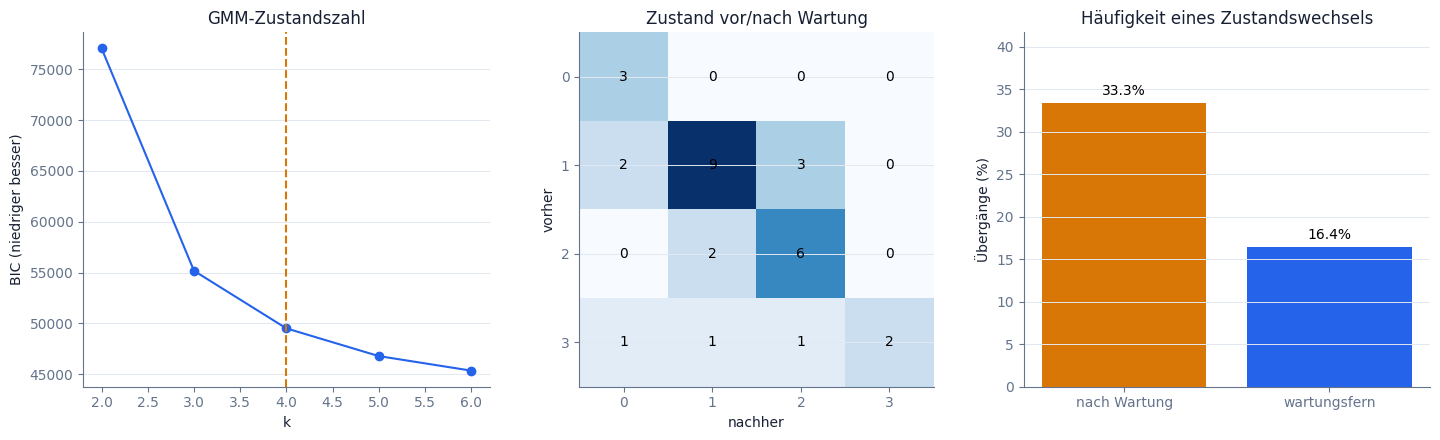

In [10]:
def timestamp_slice(start_time, end_time):
    start = int(timestamps.searchsorted(start_time, side="left"))
    end = int(timestamps.searchsorted(end_time, side="right"))
    return start, end

def probability_for_window(start_time, end_time, station):
    start, end = timestamp_slice(start_time, end_time)
    row = pd.DataFrame([temporal_feature_row(start, end, station)], columns=TEMPORAL_FEATURES)
    return temporal_gmm.predict_proba(transform_temporal(row))[0][ordered_raw_states]

transition_rows = []
for visit in eligible_visits.itertuples(index=False):
    station = int(visit.node_index)
    pre_probability = probability_for_window(visit.pre_start_utc, visit.pre_end_utc, station)
    post_probability = probability_for_window(visit.post_start_utc, visit.post_end_utc, station)
    pre_state, post_state = int(pre_probability.argmax()), int(post_probability.argmax())
    transition_rows.append({
        "visit_id": visit.visit_id, "node_code": visit.node_code,
        "visit_start_utc": visit.visit_start_utc, "actions": visit.actions,
        "pre_state": pre_state, "post_state": post_state,
        "state_changed": pre_state != post_state,
        "pre_max_probability": float(pre_probability.max()),
        "post_max_probability": float(post_probability.max()),
        "post_probability_of_pre_state": float(post_probability[pre_state]),
        "pre_expected_thermal_index": float(pre_probability @ risk_positions),
        "post_expected_thermal_index": float(post_probability @ risk_positions),
        "jensen_shannon_divergence": float(jensenshannon(pre_probability, post_probability, base=2) ** 2),
        **{f"pre_prob_state_{state}": float(pre_probability[state]) for state in range(selected_temporal_k)},
        **{f"post_prob_state_{state}": float(post_probability[state]) for state in range(selected_temporal_k)},
    })
maintenance_transitions = pd.DataFrame(transition_rows)
maintenance_transitions["thermal_index_change"] = (
    maintenance_transitions["post_expected_thermal_index"]
    - maintenance_transitions["pre_expected_thermal_index"]
)

regular_rows = []
regular = rolling_probabilities.loc[~rolling_probabilities["maintenance_near"]]
for meter_id, group in regular.groupby("meter_id"):
    by_start = {int(row.start_index): row for row in group.itertuples(index=False)}
    for start, before in by_start.items():
        after = by_start.get(start + WINDOW_HOURS)
        if after is not None:
            regular_rows.append({
                "node_code": before.node_code,
                "state_changed": before.state != after.state,
            })
regular_transitions = pd.DataFrame(regular_rows)
maintenance_change_rate = float(maintenance_transitions["state_changed"].mean())
regular_change_rate = float(regular_transitions["state_changed"].mean())
transition_summary = pd.DataFrame([
    ["nach Wartung", len(maintenance_transitions), int(maintenance_transitions["state_changed"].sum()), maintenance_change_rate],
    ["gewöhnlich, wartungsfern", len(regular_transitions), int(regular_transitions["state_changed"].sum()), regular_change_rate],
], columns=["Vergleich", "Übergänge", "Zustandswechsel", "Wechselquote"])
display(transition_summary.assign(Wechselquote=lambda d: d["Wechselquote"].map(lambda x: f"{x:.1%}")))

transition_table = pd.crosstab(
    maintenance_transitions["pre_state"], maintenance_transitions["post_state"]
).reindex(index=range(selected_temporal_k), columns=range(selected_temporal_k), fill_value=0)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))
axes[0].plot(temporal_k_metrics["k"], temporal_k_metrics["BIC"], marker="o", color=BLUE)
axes[0].axvline(selected_temporal_k, color=ORANGE, linestyle="--")
axes[0].set(title="GMM-Zustandszahl", xlabel="k", ylabel="BIC (niedriger besser)")
image = axes[1].imshow(transition_table.to_numpy(), cmap="Blues", vmin=0)
axes[1].set(title="Zustand vor/nach Wartung", xlabel="nachher", ylabel="vorher")
axes[1].set_xticks(range(selected_temporal_k)); axes[1].set_yticks(range(selected_temporal_k))
for row in range(selected_temporal_k):
    for column in range(selected_temporal_k):
        axes[1].text(column, row, int(transition_table.iloc[row, column]), ha="center", va="center")
rates = [maintenance_change_rate * 100, regular_change_rate * 100]
axes[2].bar(["nach Wartung", "wartungsfern"], rates, color=[ORANGE, BLUE])
axes[2].set(title="Häufigkeit eines Zustandswechsels", ylabel="Übergänge (%)", ylim=(0, max(40, max(rates) * 1.25)))
for index, value in enumerate(rates):
    axes[2].text(index, value + 1, f"{value:.1f}%", ha="center")
for ax in axes:
    ax.grid(axis="y", color=GRID, linewidth=.7)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUTS / "03_gmm_und_wartungswechsel.png", dpi=180, bbox_inches="tight")
plt.show()

### Schritt 17 – Wo Berechnung endet und unsere Interpretation beginnt

**BERECHNET:** Vor- und Nachherfenster haben je einen Wahrscheinlichkeitsvektor und einen
wahrscheinlichsten Zustand. Das Modell zählt, wie oft dieser Zustand gleich bleibt oder
wechselt.

**METHODISCHE ENTSCHEIDUNG / OPERATIONALE PROXY-REGEL:**

- wahrscheinlichster Zustand nach Wartung unverändert → `proxy_normal = 0`
- wahrscheinlichster Zustand nach Wartung verändert → `proxy_anomaly = 1`

Damit ist „unverändert“ für diesen Benchmark die gewünschte stabile Referenz. Das wurde nicht
vom GMM bewiesen, sondern bewusst als gemeinsame Bewertungsregel festgelegt. Ein Wechsel kann
fachlich trotzdem günstig oder ungünstig sein. Deshalb bleiben Wahrscheinlichkeitsvektor und
thermische Richtung in der Ergebnistabelle erhalten.

,proxy_label,proxy_class,Wartungen
0,0,Proxy-Normal: Zustand stabil,20
1,1,Proxy-Anomalie: Zustand gewechselt,10


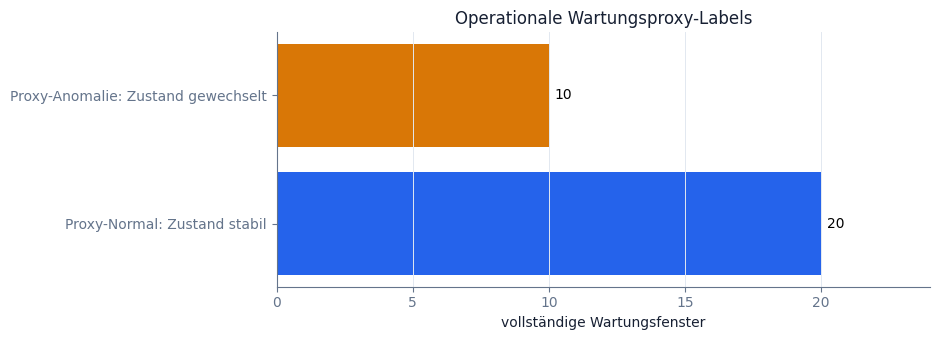

In [11]:
window_columns = ["visit_id", "post_start_utc", "post_end_utc"]
proxy_labels = maintenance_transitions.merge(
    eligible_visits[window_columns], on="visit_id", how="left", validate="one_to_one"
)
proxy_labels["proxy_label"] = proxy_labels["state_changed"].astype(int)
proxy_labels["proxy_class"] = np.where(
    proxy_labels["proxy_label"].eq(1), "Proxy-Anomalie: Zustand gewechselt",
    "Proxy-Normal: Zustand stabil",
)
proxy_events = proxy_labels.loc[proxy_labels["proxy_label"].eq(1), [
    "visit_id", "node_code", "post_start_utc", "post_end_utc"
]].rename(columns={"visit_id": "event_id", "post_start_utc": "start_utc", "post_end_utc": "end_utc"})
proxy_events["fault_type"] = "wartungsnaher_zustandswechsel"
proxy_events["confirmed_eligible"] = True
proxy_normals = proxy_labels.loc[proxy_labels["proxy_label"].eq(0), [
    "visit_id", "node_code", "post_start_utc", "post_end_utc"
]].rename(columns={"visit_id": "event_id", "post_start_utc": "start_utc", "post_end_utc": "end_utc"})
proxy_normals["confirmed_eligible"] = True

label_counts = proxy_labels.groupby(["proxy_label", "proxy_class"]).size().rename("Wartungen").reset_index()
display(label_counts)
fig, ax = plt.subplots(figsize=(9.5, 3.5))
colors = [BLUE if label == 0 else ORANGE for label in label_counts["proxy_label"]]
bars = ax.barh(label_counts["proxy_class"], label_counts["Wartungen"], color=colors)
ax.bar_label(bars, padding=4)
ax.set(title="Operationale Wartungsproxy-Labels", xlabel="vollständige Wartungsfenster", xlim=(0, 24))
ax.grid(axis="x", color=GRID, linewidth=.7); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(OUTPUTS / "04_proxy_labels.png", dpi=180, bbox_inches="tight")
plt.show()

### Schritt 18 – Unabhängige Anomaliescores auf derselben Stundenpipeline

Die Proxy-Labels stammen aus dem zeitlichen GMM. Damit die Bewertung nicht zirkulär wird,
werden sie **nicht** zur Modellanpassung benutzt und das GMM bewertet nicht sich selbst.
Verglichen werden vier unabhängige, unüberwachte Scores:

- saisonale 24-h-Abweichung,
- Isolation Forest,
- PCA-Rekonstruktionsfehler,
- Distanz zu MiniBatch-K-Means-Zentren auf Stundenebene.

Alle erhalten dieselben sechs skalierten Stundenmerkmale. Der Fit verwendet die ersten 60 %,
die Schwelle die folgenden 20 %, und ausgewertet wird ab Beginn der Validierung. Wartungsnahe
Stunden sind aus Fit und Schwellenkalibrierung ausgeschlossen.

In [12]:
MODEL_FEATURES = [
    "power_kw", "flow_lh", "delta_t_c", "flow_temp_c",
    "return_temp_c", "physics_residual_kw",
]
model_indices = [feature_index[name] for name in MODEL_FEATURES]
raw_model = values[:, :, model_indices].astype(np.float32)
model_missing = original_missing[:, :, model_indices].astype(bool)
train_values = raw_model[:train_end]
center = np.nanmedian(train_values, axis=0)
global_center = np.nanmedian(train_values, axis=(0, 1))
center = np.where(np.isfinite(center), center, global_center[None])
mad = np.nanmedian(np.abs(train_values - center[None]), axis=0)
global_mad = np.nanmedian(np.abs(train_values - global_center[None, None]), axis=(0, 1))
fallback_scale = np.maximum(1.4826 * global_mad, 1e-3)
scale = 1.4826 * mad
scale = np.where(np.isfinite(scale) & (scale > 1e-3), scale, fallback_scale[None])
filled = np.where(np.isfinite(raw_model), raw_model, center[None])
X_hourly = np.clip((filled - center[None]) / scale[None], -20, 20).astype(np.float32)

target_indices = [MODEL_FEATURES.index(name) for name in ["power_kw", "flow_lh", "delta_t_c"]]
target_available = np.isfinite(raw_model[:, :, target_indices]).all(axis=2)
train_indices = np.arange(0, train_end)
validation_indices = np.arange(train_end, val_end)
evaluation_indices = np.arange(train_end, len(timestamps))
evaluation_timestamps = timestamps[evaluation_indices]
fit_allowed = target_available & ~maintenance_exclusion

rng = np.random.default_rng(RANDOM_STATE)
eligible_train_times = np.arange(168, train_end)
sample_time_count = min(len(eligible_train_times), max(250, 100_000 // len(meter_ids)))
sampled_train_times = np.sort(rng.choice(eligible_train_times, sample_time_count, replace=False))
train_matrix_full = X_hourly[sampled_train_times].reshape(-1, len(MODEL_FEATURES))
train_row_mask = fit_allowed[sampled_train_times].reshape(-1)
train_matrix = train_matrix_full[train_row_mask]

raw_score_map = {}
seasonal = np.full((len(timestamps), len(meter_ids)), np.nan, dtype=np.float32)
seasonal_residual = np.abs(
    X_hourly[24:, :, target_indices] - X_hourly[:-24, :, target_indices]
)
seasonal[24:] = np.sort(seasonal_residual, axis=2)[:, :, -2:].mean(axis=2)
seasonal[~target_available] = np.nan
raw_score_map["Saisonale 24-h-Abweichung"] = seasonal[evaluation_indices]

hourly_iforest = IsolationForest(
    n_estimators=160, max_samples=min(20_000, len(train_matrix)),
    contamination="auto", random_state=42, n_jobs=-1,
).fit(train_matrix)
eval_matrix = X_hourly[evaluation_indices].reshape(-1, len(MODEL_FEATURES))
iforest_score = -hourly_iforest.score_samples(eval_matrix).reshape(len(evaluation_indices), len(meter_ids))
iforest_score[~target_available[evaluation_indices]] = np.nan
raw_score_map["Isolation Forest"] = iforest_score.astype(np.float32)

hourly_pca = PCA(n_components=4, random_state=42).fit(train_matrix)
reconstructed = hourly_pca.inverse_transform(hourly_pca.transform(eval_matrix))
pca_score = np.mean((eval_matrix - reconstructed) ** 2, axis=1).reshape(len(evaluation_indices), len(meter_ids))
pca_score[~target_available[evaluation_indices]] = np.nan
raw_score_map["PCA-Rekonstruktionsfehler"] = pca_score.astype(np.float32)

hourly_kmeans = MiniBatchKMeans(
    n_clusters=12, batch_size=2048, n_init=10, random_state=42
).fit(train_matrix)
kmeans_distance = hourly_kmeans.transform(eval_matrix).min(axis=1).reshape(len(evaluation_indices), len(meter_ids))
kmeans_distance[~target_available[evaluation_indices]] = np.nan
raw_score_map["Stunden-K-Means-Distanz"] = kmeans_distance.astype(np.float32)
print(f"Gemeinsame Trainingsmatrix: {train_matrix.shape[0]:,} Stationsstunden × {train_matrix.shape[1]} Merkmale")

Gemeinsame Trainingsmatrix: 54,203 Stationsstunden × 6 Merkmale


In [13]:
def build_interval_mask(intervals, time_axis, nodes):
    node_index = {node: index for index, node in enumerate(map(str, nodes))}
    mask = np.zeros((len(time_axis), len(nodes)), dtype=bool)
    for row in intervals.itertuples(index=False):
        if str(row.node_code) not in node_index:
            continue
        start = int(np.searchsorted(time_axis.values, np.datetime64(row.start_utc), side="left"))
        end = int(np.searchsorted(time_axis.values, np.datetime64(row.end_utc), side="right"))
        start, end = max(0, start), min(len(time_axis), end)
        if end > start:
            mask[start:end, node_index[str(row.node_code)]] = True
    return mask

def persistent_points(binary, minimum_length=3):
    output = np.zeros_like(binary, dtype=bool)
    for node in range(binary.shape[1]):
        changes = np.diff(np.r_[False, binary[:, node], False].astype(np.int8))
        for start, end in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
            if end - start >= minimum_length:
                output[start:end, node] = True
    return output

def predicted_runs(binary):
    runs = []
    for node in range(binary.shape[1]):
        changes = np.diff(np.r_[False, binary[:, node], False].astype(np.int8))
        runs.extend((node, int(start), int(end)) for start, end in zip(
            np.where(changes == 1)[0], np.where(changes == -1)[0]
        ))
    return runs

event_mask = build_interval_mask(proxy_events, evaluation_timestamps, node_codes)
normal_mask = build_interval_mask(proxy_normals, evaluation_timestamps, node_codes)
if np.any(event_mask & normal_mask):
    raise ValueError("Proxy-Ereignis- und Normalmasken überlappen.")

validation_in_eval = np.arange(0, val_end - train_end)
calibration_allowed = (
    fit_allowed[validation_indices]
    & ~event_mask[validation_in_eval]
    & ~normal_mask[validation_in_eval]
)

def normalize_scores(raw_scores, quantile=THRESHOLD_QUANTILE):
    raw_scores = np.asarray(raw_scores, dtype=float)
    if raw_scores.shape == (len(timestamps), len(node_codes)):
        raw_scores = raw_scores[evaluation_indices]
    if raw_scores.shape != (len(evaluation_indices), len(node_codes)):
        raise ValueError(
            f"Scores brauchen Form {(len(evaluation_indices), len(node_codes))} "
            f"oder {(len(timestamps), len(node_codes))}; erhalten {raw_scores.shape}."
        )
    calibration = raw_scores[validation_in_eval].copy()
    calibration[~calibration_allowed] = np.nan
    thresholds = np.nanquantile(calibration, quantile, axis=0)
    valid = np.isfinite(thresholds) & (thresholds > 1e-8)
    pooled = float(np.nanquantile(calibration, quantile))
    thresholds = np.where(valid, thresholds, pooled)
    return raw_scores / thresholds[None], thresholds

def evaluate_normalized_scores(score_map):
    metric_rows, detection_rows = [], []
    node_index = {node: index for index, node in enumerate(node_codes)}
    for model_name, score in score_map.items():
        persistent = persistent_points(
            np.isfinite(score) & (score > 1.0), MIN_ALARM_RUN_HOURS
        )
        detected_count, delays, localized_values = 0, [], []
        for event in proxy_events.itertuples(index=False):
            station = node_index[str(event.node_code)]
            start = int(np.searchsorted(evaluation_timestamps.values, np.datetime64(event.start_utc), side="left"))
            end = int(np.searchsorted(evaluation_timestamps.values, np.datetime64(event.end_utc), side="right"))
            hits = np.flatnonzero(persistent[start:end, station]) if end > start else np.array([])
            detected = len(hits) > 0
            delay = np.nan
            if detected:
                detected_count += 1
                first_time = evaluation_timestamps[start + int(hits[0])]
                delay = max(0.0, (first_time - event.start_utc).total_seconds() / 3600)
                delays.append(delay)
            window = score[start:end]
            top_station = int(np.nanargmax(np.nanmax(window, axis=0))) if np.isfinite(window).any() else None
            localized = top_station == station
            localized_values.append(localized)
            detection_rows.append({
                "Modell": model_name, "event_id": event.event_id,
                "detected": detected, "delay_hours": delay,
                "localized": localized,
            })

        matched_runs = false_runs = unknown_runs = 0
        for station, start, end in predicted_runs(persistent):
            if event_mask[start:end, station].any():
                matched_runs += 1
            elif normal_mask[start:end, station].any():
                false_runs += 1
            else:
                unknown_runs += 1
        classified = matched_runs + false_runs
        precision = matched_runs / classified if classified else np.nan
        recall = detected_count / len(proxy_events) if len(proxy_events) else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if classified and precision + recall else (0.0 if classified else np.nan)
        )
        normal_hours = int(normal_mask.sum())
        metric_rows.append({
            "Modell": model_name, "events_total": len(proxy_events),
            "events_detected": detected_count, "event_recall": recall,
            "event_precision_in_labeled_windows": precision, "event_f1": f1,
            "median_delay_hours": float(np.median(delays)) if delays else np.nan,
            "localization_accuracy": float(np.mean(localized_values)) if localized_values else np.nan,
            "false_alarm_runs_in_proxy_normal": false_runs,
            "false_alarm_runs_per_normal_station_week": false_runs / (normal_hours / 168),
            "unknown_alarm_runs_excluded": unknown_runs,
        })
    return pd.DataFrame(metric_rows).sort_values(
        ["event_recall", "false_alarm_runs_in_proxy_normal"], ascending=[False, True]
    ).reset_index(drop=True), pd.DataFrame(detection_rows)

normalized_score_map, score_thresholds = {}, {}
for model_name, raw_score in raw_score_map.items():
    normalized_score_map[model_name], score_thresholds[model_name] = normalize_scores(raw_score)
event_metrics, event_detection = evaluate_normalized_scores(normalized_score_map)
display(event_metrics.round(3))

,Modell,events_total,events_detected,event_recall,event_precision_in_labeled_windows,event_f1,median_delay_hours,localization_accuracy,false_alarm_runs_in_proxy_normal,false_alarm_runs_per_normal_station_week,unknown_alarm_runs_excluded
0,Isolation Forest,10,2,0.200,1.000,0.333,123.442,0.000,0,0.000,160
1,PCA-Rekonstruktionsfehler,10,2,0.200,0.296,0.239,33.533,0.100,19,0.474,730
2,Stunden-K-Means-Distanz,10,1,0.100,0.667,0.174,145.000,0.000,1,0.025,105
3,Saisonale 24-h-Abweichung,10,0,0.000,0.000,0.000,NaN,0.100,2,0.050,85


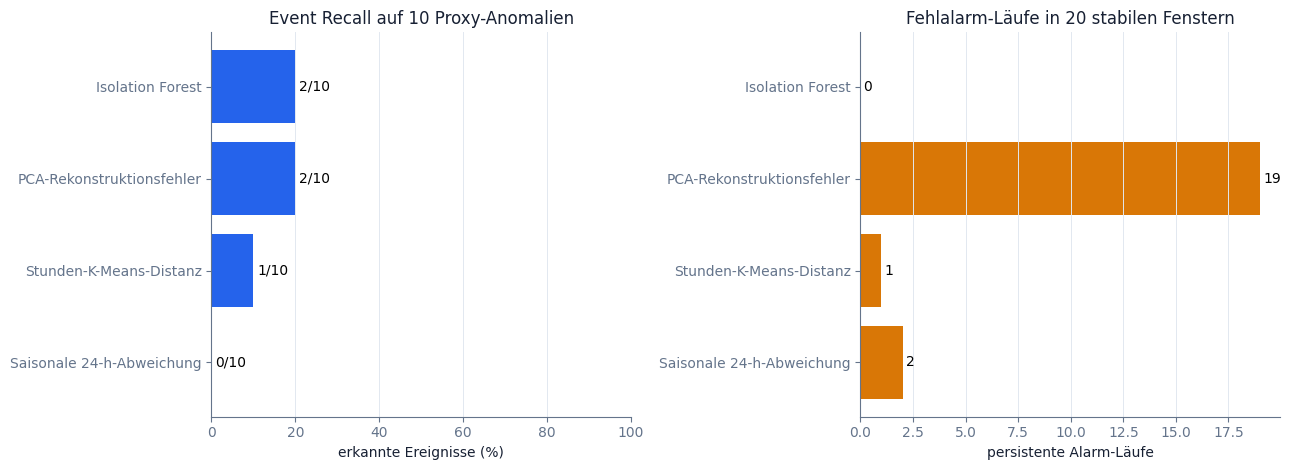

In [14]:
plot_order = event_metrics.sort_values("event_recall", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].barh(plot_order["Modell"], plot_order["event_recall"] * 100, color=BLUE)
axes[0].set(title="Event Recall auf 10 Proxy-Anomalien", xlabel="erkannte Ereignisse (%)", xlim=(0, 100))
for index, row in enumerate(plot_order.itertuples(index=False)):
    axes[0].text(row.event_recall * 100 + 1, index,
                 f"{int(row.events_detected)}/{int(row.events_total)}", va="center")
axes[1].barh(plot_order["Modell"], plot_order["false_alarm_runs_in_proxy_normal"], color=ORANGE)
axes[1].set(title="Fehlalarm-Läufe in 20 stabilen Fenstern", xlabel="persistente Alarm-Läufe")
for index, value in enumerate(plot_order["false_alarm_runs_in_proxy_normal"]):
    axes[1].text(value + .15, index, str(int(value)), va="center")
for ax in axes:
    ax.grid(axis="x", color=GRID, linewidth=.7)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUTS / "05_eventbenchmark.png", dpi=180, bbox_inches="tight")
plt.show()

### Eigene Modelle auf exakt derselben Verarbeitung testen

Andere Teammitglieder müssen die Bereinigung nicht kopieren. `MODEL_DATA` ist die gemeinsame
Schnittstelle. Ein eigenes Modell darf nur `train_indices` und `fit_allowed` zum Fit benutzen.
Es erzeugt anschließend pro Stunde und HAST einen Score, bei dem größere Werte auffälliger
sind. `evaluate_custom_scores` übernimmt dieselbe Validierungsschwelle, 3-Stunden-Regel und
Eventauswertung wie oben.

Minimaler Ablauf:

```python
X = MODEL_DATA["X"]
train = MODEL_DATA["train_indices"]
allowed = MODEL_DATA["fit_allowed"][train]
train_rows = X[train].reshape(-1, X.shape[-1])[allowed.reshape(-1)]

mein_modell.fit(train_rows)
scores = mein_modell_score_pro_stunde_und_hast  # Form Zeit×HAST, größer = auffälliger
meine_metriken, meine_events = evaluate_custom_scores(scores, "Mein Modell")
```

Damit sind Modelle vergleichbar, obwohl ihre interne Methode verschieden ist.

In [15]:
MODEL_DATA = {
    "X": X_hourly,
    "missing": model_missing,
    "timestamps": timestamps,
    "node_codes": node_codes,
    "feature_names": MODEL_FEATURES,
    "train_indices": train_indices,
    "validation_indices": validation_indices,
    "evaluation_indices": evaluation_indices,
    "fit_allowed": fit_allowed,
    "maintenance_exclusion": maintenance_exclusion,
    "proxy_events": proxy_events.copy(),
    "proxy_normals": proxy_normals.copy(),
}

def evaluate_custom_scores(raw_scores, model_name="Eigenes Modell"):
    """Bewertet Zeit×HAST-Scores mit dem gemeinsamen, leakage-freien Vertrag."""
    normalized, _ = normalize_scores(raw_scores)
    metrics, detections = evaluate_normalized_scores({model_name: normalized})
    return metrics, detections

# Schnittstellen-Selbsttest: derselbe Isolation-Forest-Score muss dasselbe Ergebnis liefern.
interface_metrics, _ = evaluate_custom_scores(
    raw_score_map["Isolation Forest"], "Isolation Forest"
)
expected_recall = event_metrics.set_index("Modell").loc["Isolation Forest", "event_recall"]
assert np.isclose(interface_metrics.iloc[0]["event_recall"], expected_recall)
print("Modellschnittstelle geprüft: eigene Scores können direkt verglichen werden.")

Modellschnittstelle geprüft: eigene Scores können direkt verglichen werden.


## Takeaways

### Ergebnisse speichern und den alleinigen Lauf prüfen

In [16]:
public_station_columns = [
    "node_code", "cluster", "profile", *STATION_FEATURES,
    "score_kmeans_distance", "score_isolation_forest", "score_lof",
    "score_cluster_robust", "visits", "confirmed_visits", "total_actions",
    "has_confirmed_maintenance",
]
station_public = station_private[public_station_columns].copy()
public_transition_columns = [
    column for column in maintenance_transitions.columns if column != "meter_id"
]
public_rolling_columns = [
    "window_start", "window_end", "window_center", "node_code", "maintenance_near",
    *TEMPORAL_FEATURES, *probability_columns, "state", "max_probability",
    "expected_thermal_index",
]
station_k_metrics.to_csv(ARTIFACTS / "station_k_metrics.csv", index=False)
cluster_summary.to_csv(ARTIFACTS / "station_cluster_summary.csv", index=False)
station_public.to_csv(ARTIFACTS / "station_profiles_and_scores.csv", index=False)
temporal_k_metrics.to_csv(ARTIFACTS / "temporal_gmm_k_metrics.csv", index=False)
state_profiles.to_csv(ARTIFACTS / "temporal_state_profiles.csv", index=False)
rolling_probabilities[public_rolling_columns].to_csv(
    ARTIFACTS / "temporal_state_probabilities.csv", index=False
)
maintenance_transitions[public_transition_columns].to_csv(
    ARTIFACTS / "maintenance_state_transitions.csv", index=False
)
proxy_labels.drop(columns=[column for column in ["meter_id"] if column in proxy_labels]).to_csv(
    ARTIFACTS / "maintenance_proxy_labels.csv", index=False
)
event_metrics.to_csv(ARTIFACTS / "event_metrics.csv", index=False)
event_detection.to_csv(ARTIFACTS / "event_detection.csv", index=False)
np.savez_compressed(
    ARTIFACTS / "shared_model_data.npz",
    X=X_hourly, missing=model_missing.astype(np.uint8),
    timestamps=timestamps.to_numpy(dtype="datetime64[ns]").astype("int64"),
    node_codes=node_codes, feature_names=np.asarray(MODEL_FEATURES),
    train_indices=train_indices, validation_indices=validation_indices,
    evaluation_indices=evaluation_indices, fit_allowed=fit_allowed.astype(np.uint8),
)
joblib.dump({
    "station_kmeans": kmeans_station, "temporal_gmm": temporal_gmm,
    "hourly_isolation_forest": hourly_iforest, "hourly_pca": hourly_pca,
    "hourly_kmeans": hourly_kmeans,
}, MODELS / "standalone_models.joblib")

stable_count = int(proxy_labels["proxy_label"].eq(0).sum())
changed_count = int(proxy_labels["proxy_label"].eq(1).sum())
checks = pd.DataFrame([
    ["keine vorberechnete Eingabe", True, "alle Eingaben stammen aus DATA_ROOT"],
    ["Stundenachse", len(timestamps) == 18_518, f"{len(timestamps):,}"],
    ["HAST-Achse", len(node_codes) == 78, str(len(node_codes))],
    ["K-Means-k", selected_station_k == 2, f"k={selected_station_k}"],
    ["GMM-k", selected_temporal_k == 4, f"k={selected_temporal_k}"],
    ["30 Wartungen verbunden", len(proxy_labels) == 30, str(len(proxy_labels))],
    ["20 stabile Proxy-Normalfenster", stable_count == 20, str(stable_count)],
    ["10 Proxy-Anomaliefenster", changed_count == 10, str(changed_count)],
    ["Wahrscheinlichkeiten summieren zu 1", np.allclose(probabilities.sum(axis=1), 1, atol=1e-6),
     f"max. Fehler {np.max(np.abs(probabilities.sum(axis=1)-1)):.2e}"],
    ["eigene Modellschnittstelle", True, "Selbsttest bestanden"],
], columns=["Prüfung", "bestanden", "Evidenz"])
checks["Status"] = checks["bestanden"].map({True: "OK", False: "FEHLER"})
display(checks[["Prüfung", "Status", "Evidenz"]])
if not checks["bestanden"].all():
    raise AssertionError("Mindestens eine Abschlussprüfung ist fehlgeschlagen.")

best_model = event_metrics.iloc[0]
cluster_sizes = cluster_summary.sort_values("cluster")["stations"].astype(int).tolist()
display(Markdown(f"""\
### Was tatsächlich herausgefunden wurde

1. **BERECHNET:** Aus {len(zip_meter_ids)} Zählern im neuesten Export werden über Topologie
   und 60%-Abdeckung **{len(node_codes)} HAST** mit **{len(timestamps):,} gemeinsamen
   Stunden**. Die Adress-Zähler-Zuordnung ist für die Wartungsanalyse vorhanden.
2. **BERECHNET:** Die dokumentierte Stationslösung ist **K-Means k={selected_station_k}**
   mit Clustergrößen **{cluster_sizes}**. **INTERPRETATION:** Das sind ähnliche
   Betriebsprofile, keine Fehlerklassen.
3. **BERECHNET:** Das zeitliche GMM nutzt **{selected_temporal_k} Zustände**. Nach
   {len(proxy_labels)} Wartungen bleiben **{stable_count}** wahrscheinlichste Zustände
   gleich und **{changed_count}** wechseln; wartungsfern liegt die Wechselquote bei
   **{regular_change_rate:.1%}**, nach Wartung bei **{maintenance_change_rate:.1%}**.
4. **INTERPRETATION/PROXY:** Für den gemeinsamen Benchmark zählen die {stable_count}
   unveränderten Fenster als Normalreferenz und die {changed_count} Wechsel als Anomalie.
   Das sind nutzbare Vergleichslabels, aber keine bestätigten Fehlerarten.
5. **BERECHNET:** Im unabhängigen Stundenbenchmark erkennt **{best_model['Modell']}**
   **{int(best_model['events_detected'])}/{int(best_model['events_total'])}**
   Proxy-Anomalien. In den 20 stabilen Fenstern entstehen
   **{int(best_model['false_alarm_runs_in_proxy_normal'])}** persistente Fehlalarm-Läufe.
6. **NICHT BELEGT:** Ein Clusterwechsel beweist weder einen Defekt noch die Wirkung der
   Wartung. Das Ergebnis ist ein reproduzierbarer Wartungsproxy-Benchmark, kein fertig
   validiertes Diagnosesystem.

### Was danach kommt

Eigene Modelle werden über `MODEL_DATA` trainiert und mit `evaluate_custom_scores` auf
exakt demselben Split, denselben Proxy-Ereignissen und denselben Alarmregeln verglichen.
Ein Modell ist nur dann praktisch besser, wenn es mehr der zehn Ereignisse erkennt, ohne
zugleich mehr Fehlalarm-Läufe in den 20 stabilen Fenstern zu erzeugen. Außentemperatur,
Gebäudenutzung oder manuelle Fehlerarten wären spätere Erweiterungen, aber keine Voraussetzung
für den hier definierten Vergleich.
"""))
print("Alle Checks bestanden. Dieses Notebook wurde vollständig aus den Rohdaten erzeugt.")

,Prüfung,Status,Evidenz
0,keine vorberechnete Eingabe,OK,alle Eingaben stammen aus DATA_ROOT
1,Stundenachse,OK,"18,518"
2,HAST-Achse,OK,78
3,K-Means-k,OK,k=2
4,GMM-k,OK,k=4
5,30 Wartungen verbunden,OK,30
6,20 stabile Proxy-Normalfenster,OK,20
7,10 Proxy-Anomaliefenster,OK,10
8,Wahrscheinlichkeiten summieren zu 1,OK,max. Fehler 1.78e-15
9,eigene Modellschnittstelle,OK,Selbsttest bestanden


### Was tatsächlich herausgefunden wurde

1. **BERECHNET:** Aus 96 Zählern im neuesten Export werden über Topologie
   und 60%-Abdeckung **78 HAST** mit **18,518 gemeinsamen
   Stunden**. Die Adress-Zähler-Zuordnung ist für die Wartungsanalyse vorhanden.
2. **BERECHNET:** Die dokumentierte Stationslösung ist **K-Means k=2**
   mit Clustergrößen **[54, 24]**. **INTERPRETATION:** Das sind ähnliche
   Betriebsprofile, keine Fehlerklassen.
3. **BERECHNET:** Das zeitliche GMM nutzt **4 Zustände**. Nach
   30 Wartungen bleiben **20** wahrscheinlichste Zustände
   gleich und **10** wechseln; wartungsfern liegt die Wechselquote bei
   **16.4%**, nach Wartung bei **33.3%**.
4. **INTERPRETATION/PROXY:** Für den gemeinsamen Benchmark zählen die 20
   unveränderten Fenster als Normalreferenz und die 10 Wechsel als Anomalie.
   Das sind nutzbare Vergleichslabels, aber keine bestätigten Fehlerarten.
5. **BERECHNET:** Im unabhängigen Stundenbenchmark erkennt **Isolation Forest**
   **2/10**
   Proxy-Anomalien. In den 20 stabilen Fenstern entstehen
   **0** persistente Fehlalarm-Läufe.
6. **NICHT BELEGT:** Ein Clusterwechsel beweist weder einen Defekt noch die Wirkung der
   Wartung. Das Ergebnis ist ein reproduzierbarer Wartungsproxy-Benchmark, kein fertig
   validiertes Diagnosesystem.

### Was danach kommt

Eigene Modelle werden über `MODEL_DATA` trainiert und mit `evaluate_custom_scores` auf
exakt demselben Split, denselben Proxy-Ereignissen und denselben Alarmregeln verglichen.
Ein Modell ist nur dann praktisch besser, wenn es mehr der zehn Ereignisse erkennt, ohne
zugleich mehr Fehlalarm-Läufe in den 20 stabilen Fenstern zu erzeugen. Außentemperatur,
Gebäudenutzung oder manuelle Fehlerarten wären spätere Erweiterungen, aber keine Voraussetzung
für den hier definierten Vergleich.


Alle Checks bestanden. Dieses Notebook wurde vollständig aus den Rohdaten erzeugt.
